# 11 - Real vs Synthetic BOAMP Benchmark Comparison

## tl;dr

This notebook is the visual evidence dashboard for the final synthetic
benchmark, `v0_3_temporal_candidate_revision`. It compares the original
prepared BOAMP dataset with the observed v0.3 synthetic benchmark and shows:

- high-level dataset composition;
- observable-field similarity;
- temporal/calendar similarity;
- Layer-1 candidate-environment similarity;
- distribution checks for text length, duration, CPV division, and buyer activity;
- final readiness gates and caveats.

The synthetic benchmark is used as a controlled evaluation environment. It
does **not** replace the original real dataset and does **not** prove true
real-world renewal labels.


## Context & Sources

In [1]:
import json
import math
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from boamp.config import load_config
from boamp.data.prepare import tag_digital_scope
from boamp.linkage.candidates import generate_pairs_single_key
from boamp.reporting.figures import setup_style
from boamp.synthetic.compatibility import adapt_observed_notices_to_sources
from utils.text_clean import normalize_objet

setup_style()
sns.set_theme(style="whitegrid", context="notebook")

cfg = load_config(PROJECT_ROOT)

VERSION = "v0_3_temporal_candidate_revision"
PREVIOUS_VERSION = "v0_2_conditional_revision"
SCENARIO = "central_provisional"

REAL_PATH = PROJECT_ROOT / "data/interim/boamp_common_prepared.csv"
REAL_SOURCES_PATH = PROJECT_ROOT / "data/processed/boamp_only/boamp_only_sources.csv"
REAL_PAIRS_PATH = PROJECT_ROOT / "data/processed/boamp_only/boamp_only_candidate_pairs.csv"

SYN_DIR = (
    PROJECT_ROOT
    / "data/processed/synthetic_benchmark"
    / VERSION
    / SCENARIO
    / "world_001/corruption_001"
)
SYN_OBSERVED_PATH = SYN_DIR / "observed_notices.parquet"
SYN_TRUE_RELATIONS_PATH = SYN_DIR / "true_relations.parquet"
SYN_METADATA_PATH = SYN_DIR / "generation_metadata.json"

SOURCE_TABLE_DIR = PROJECT_ROOT / "reports/tables/synthetic_benchmark" / VERSION
OUT_TABLES = PROJECT_ROOT / "reports/tables/synthetic_benchmark/v0_3_real_synthetic_comparison"
OUT_FIGURES = PROJECT_ROOT / "reports/figures/synthetic_benchmark/v0_3_real_synthetic_comparison"
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_FIGURES.mkdir(parents=True, exist_ok=True)
SYN_OBSERVED_CSV_PATH = OUT_TABLES / "synthetic_observed_notices_v0_3.csv"

REAL_COLOR = "#2a78d6"
SYN_COLOR = "#eb6834"
V2_COLOR = "#9a9a95"
DIFF_COLOR = "#b34d4d"
NEUTRAL = "#4d4d4d"

PLOT_DPI = 160

source_inventory = pd.DataFrame(
    [
        {"source": "prepared real corpus", "path": REAL_PATH.relative_to(PROJECT_ROOT), "purpose": "full-corpus observable comparison"},
        {"source": "real Layer-1 sources", "path": REAL_SOURCES_PATH.relative_to(PROJECT_ROOT), "purpose": "production source-scope candidate comparison"},
        {"source": "real Layer-1 candidate pairs", "path": REAL_PAIRS_PATH.relative_to(PROJECT_ROOT), "purpose": "real candidate-count baseline"},
        {"source": "synthetic observed notices", "path": SYN_OBSERVED_PATH.relative_to(PROJECT_ROOT), "purpose": "algorithm-facing synthetic data"},
        {"source": "synthetic true relations", "path": SYN_TRUE_RELATIONS_PATH.relative_to(PROJECT_ROOT), "purpose": "structural truth summary only"},
        {"source": "v0.3 validation tables", "path": SOURCE_TABLE_DIR.relative_to(PROJECT_ROOT), "purpose": "authoritative readiness/gate evidence"},
    ]
)
source_inventory.to_csv(OUT_TABLES / "source_inventory.csv", index=False)
source_inventory

,source,path,purpose
0,prepared real corpus,data/interim/boamp_common_prepared.csv,full-corpus observable comparison
1,real Layer-1 sources,data/processed/boamp_only/boamp_only_sources.csv,production source-scope candidate comparison
2,real Layer-1 candidate pairs,data/processed/boamp_only/boamp_only_candidate...,real candidate-count baseline
3,synthetic observed notices,data/processed/synthetic_benchmark/v0_3_tempor...,algorithm-facing synthetic data
4,synthetic true relations,data/processed/synthetic_benchmark/v0_3_tempor...,structural truth summary only
5,v0.3 validation tables,reports/tables/synthetic_benchmark/v0_3_tempor...,authoritative readiness/gate evidence


### Simple `pd.read_csv` Lines

The original real dataset is already a CSV. The final synthetic benchmark is
stored as Parquet in the generation output, so this notebook also writes a
CSV mirror for easy inspection. After that, both datasets can be opened with
`pd.read_csv`.


In [2]:
# Simple lines to read the two comparison datasets as CSV files.
# Real/original prepared BOAMP dataset:
real_dataset = pd.read_csv(PROJECT_ROOT / "data/interim/boamp_common_prepared.csv", low_memory=False)

# Synthetic benchmark dataset:
# The authoritative generated file is Parquet, so refresh a CSV mirror for easy notebook/report use.
pd.read_parquet(SYN_OBSERVED_PATH).to_csv(SYN_OBSERVED_CSV_PATH, index=False)
synthetic_benchmark_dataset = pd.read_csv(SYN_OBSERVED_CSV_PATH, low_memory=False)

pd.DataFrame(
    {
        "dataset": ["real_dataset", "synthetic_benchmark_dataset"],
        "rows": [len(real_dataset), len(synthetic_benchmark_dataset)],
        "columns": [len(real_dataset.columns), len(synthetic_benchmark_dataset.columns)],
        "read_line": [
            'pd.read_csv("data/interim/boamp_common_prepared.csv", low_memory=False)',
            f'pd.read_csv("{SYN_OBSERVED_CSV_PATH.relative_to(PROJECT_ROOT)}", low_memory=False)',
        ],
    }
)

,dataset,rows,columns,read_line
0,real_dataset,84623,94,"pd.read_csv(""data/interim/boamp_common_prepare..."
1,synthetic_benchmark_dataset,9471,12,"pd.read_csv(""reports/tables/synthetic_benchmar..."


### What Do The Two Datasets Look Like?

The next cells print the first rows and the column structure. This is meant
for quick human inspection before looking at the validation plots.


In [3]:
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)

overview = pd.DataFrame(
    {
        "dataset": ["real_dataset", "synthetic_benchmark_dataset"],
        "rows": [real_dataset.shape[0], synthetic_benchmark_dataset.shape[0]],
        "columns": [real_dataset.shape[1], synthetic_benchmark_dataset.shape[1]],
        "source_file": [
            str((PROJECT_ROOT / "data/interim/boamp_common_prepared.csv").relative_to(PROJECT_ROOT)),
            str(SYN_OBSERVED_CSV_PATH.relative_to(PROJECT_ROOT)),
        ],
    }
)
display(overview)

print("Real/original prepared BOAMP dataset: first 5 rows")
display(real_dataset.head(5))

print("Synthetic v0.3 benchmark observed notices: first 5 rows")
display(synthetic_benchmark_dataset.head(5))

,dataset,rows,columns,source_file
0,real_dataset,84623,94,data/interim/boamp_common_prepared.csv
1,synthetic_benchmark_dataset,9471,12,reports/tables/synthetic_benchmark/v0_3_real_synthetic_comparison/synthetic_observed_notices_v0_3.csv


Real/original prepared BOAMP dataset: first 5 rows


,idweb,id,objet,filename,famille,famille_libelle,code_departement,code_departement_prestation,dateparution,datefindiffusion,datelimitereponse,nomacheteur,titulaire,perimetre,type_procedure,soustype_procedure,procedure_libelle,nature,sousnature,nature_libelle,...,cpv_category,cpv_missing,cpv_generic_flag,is_digital_scope,category_label,is_digital_scope_cpv_only,is_in_pdl,duration_raw,declared_duration_months,duration_unit,duration_valid,duration_quality_flag,dur_was_imputed,linked_attribution_notice_id,linked_attribution_date,start_date,start_date_source,buyer_key,buyer_key_type,buyer_identity_layer
0,15-28783,15_28783,"fourniture de café avec mise à disposition des machines, pots et pichets à Saint Nazaire",BOAMP-J-AO_2015_062009,JOUE,Marchés européens,44,44.0,2015-03-03,2015-04-13,2015-04-13T15:00:00+00:00,Centre Hospitalier de Saint-Nazaire,NaN,DIRECTIVE-18,OUVERT,NaN,Procédure Ouverte,APPEL_OFFRE,NaN,Avis de marché,...,15861.0,False,False,False,OTHER,False,True,NaN,NaN,NaN,False,MISSING,False,15-95929,2015-06-23,2015-06-23,LINKED_ATTRIBUTION_DATE,NAME:centre hospitalier de saint-nazaire,NAME_FALLBACK,BOAMP_NATIVE
1,15-31324,15_31324,Prestation d'assurance pour les besoins de la ville de Pont St Martin,BOAMP-J-AO_2015_062009,JOUE,Marchés européens,44;85;72;79,44.0,2015-03-03,2015-04-13,2015-04-13T11:00:00+00:00,MAIRIE DE PONT ST MARTIN,NaN,DIRECTIVE-18,OUVERT,NaN,Procédure Ouverte,APPEL_OFFRE,NaN,Avis de marché,...,66515.0,False,False,False,OTHER,False,True,NaN,NaN,NaN,False,MISSING,False,15-117254,2015-07-28,2015-07-28,LINKED_ATTRIBUTION_DATE,NAME:mairie de pont st martin,NAME_FALLBACK,BOAMP_NATIVE
2,15-32027,15_32027,mise en service de vélos neufs classiques et pliants à Angers,BOAMP-J-AO_2015_063003,JOUE,Marchés européens,49,49.0,2015-03-03,2015-04-14,2015-04-14T11:00:00+00:00,Ville d'Angers,NaN,DIRECTIVE-18,OUVERT,NaN,Procédure Ouverte,APPEL_OFFRE,NaN,Avis de marché,...,50000.0,False,True,False,OTHER,False,True,NaN,NaN,NaN,False,MISSING,False,15-74806,2015-05-18,2015-05-18,LINKED_ATTRIBUTION_DATE,NAME:ville d angers,NAME_FALLBACK,BOAMP_NATIVE
3,15-15433,15_15433,Travaux d'étanchéité-couverture en Maine et Loire pour les lycées de la Région des Pays de la Loire et espace régional,BOAMP-J-AO_2015_064003,JOUE,Marchés européens,49,44.0,2015-03-04,2015-04-23,2015-04-23T12:00:00+00:00,Conseil régional des Pays de la Loire,NaN,DIRECTIVE-18,OUVERT,NaN,Procédure Ouverte,APPEL_OFFRE,NaN,Avis de marché,...,45454.0,False,False,False,OTHER,False,True,NaN,NaN,NaN,False,MISSING,False,NaN,NaN,2015-03-04,PUBLICATION_DATE_FALLBACK,NAME:conseil regional des pays de la loire,NAME_FALLBACK,BOAMP_NATIVE
4,15-30886,15_30886,mission de maîtrise d'oeuvre relative à l'extension de capacité de la M.A.S. 'Le Hameau de La Pairette'au profit du ...,BOAMP-J-AO_2015_062009,JOUE,Marchés européens,85,85.0,2015-03-03,2015-04-03,2015-04-03T15:00:00+00:00,Centre Hospitalier Georges Mazurelle,NaN,DIRECTIVE-18,CONCOURS_RESTREINT,NaN,Procédure Concours restreint,APPEL_OFFRE,NaN,Avis de marché,...,71000.0,False,True,False,OTHER,False,True,NaN,NaN,NaN,False,MISSING,False,15-169034,2015-11-06,2015-11-06,LINKED_ATTRIBUTION_DATE,NAME:centre hospitalier georges mazurelle,NAME_FALLBACK,BOAMP_NATIVE


Synthetic v0.3 benchmark observed notices: first 5 rows


,notice_id_synthetic,publication_date,notice_type_normalized,schema_family,buyer_siret_raw,buyer_siren_raw,buyer_name_raw,code_departement,cpv_clean,declared_duration_months,objet_clean,linked_call_notice_id
0,NOTICE-00000000,2015-02-23,APPEL_OFFRE,LEGACY,NaN,NaN,Syndicat mixte Fonbourg,44,50450874.0,NaN,Marché public - voir cahier des charges pour le détail des prestations. Marché public de maintenance des ascenseurs ...,NaN
1,NOTICE-00000001,2015-03-14,APPEL_OFFRE,LEGACY,NaN,NaN,Communauté de communes Sainsac - Service des marchés publics,49,NaN,NaN,Marché public de rénovation énergétique - Communauté de communes Sainsac - réf. 175678 - lot 1 : chantier et constru...,NaN
2,NOTICE-00000002,2015-03-29,APPEL_OFFRE,LEGACY,NaN,NaN,Syndicat mixte Saincourt,72,NaN,NaN,Marché public de prestations de services divers - Syndicat mixte Saincourt - réf. 674686 - lot 3 : service et fourni...,NaN
3,NOTICE-00000003,2015-05-26,ATTRIBUTION,LEGACY,NaN,NaN,Syndicat mixte Saincourt,72,24152017.0,NaN,Avis de marché public - prestations courantes.,NOTICE-00000002
4,NOTICE-00000004,2015-03-30,APPEL_OFFRE,LEGACY,NaN,NaN,Commune de Châteausac,72,66000000.0,NaN,Marché public de assurance dommages - Commune de Châteausac - réf. 815174 - lot 3 : sinistre et contrat.,NaN


In [4]:
def describe_columns_for_preview(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        pd.DataFrame(
            {
                "column": frame.columns,
                "dtype": [str(frame[c].dtype) for c in frame.columns],
                "missing_pct": [frame[c].isna().mean() * 100 for c in frame.columns],
                "example_value": [
                    frame[c].dropna().astype(str).head(1).iloc[0]
                    if frame[c].notna().any()
                    else ""
                    for c in frame.columns
                ],
            }
        )
        .assign(missing_pct=lambda x: x["missing_pct"].round(2))
    )

real_column_preview = describe_columns_for_preview(real_dataset)
synthetic_column_preview = describe_columns_for_preview(synthetic_benchmark_dataset)

real_column_preview.to_csv(OUT_TABLES / "real_dataset_column_preview.csv", index=False)
synthetic_column_preview.to_csv(OUT_TABLES / "synthetic_dataset_column_preview.csv", index=False)

print("Real dataset columns, dtypes, missingness, and example values")
display(real_column_preview)

print("Synthetic dataset columns, dtypes, missingness, and example values")
display(synthetic_column_preview)

Real dataset columns, dtypes, missingness, and example values


,column,dtype,missing_pct,example_value
0,idweb,object,0.0,15-28783
1,id,object,0.0,15_28783
2,objet,object,0.0,"fourniture de café avec mise à disposition des machines, pots et pichets à Saint Nazaire"
3,filename,object,0.0,BOAMP-J-AO_2015_062009
4,famille,object,0.0,JOUE
...,...,...,...,...
89,start_date,object,0.0,2015-06-23
90,start_date_source,object,0.0,LINKED_ATTRIBUTION_DATE
91,buyer_key,object,0.0,NAME:centre hospitalier de saint-nazaire
92,buyer_key_type,object,0.0,NAME_FALLBACK


Synthetic dataset columns, dtypes, missingness, and example values


,column,dtype,missing_pct,example_value
0,notice_id_synthetic,object,0.00,NOTICE-00000000
1,publication_date,object,0.00,2015-02-23
2,notice_type_normalized,object,0.00,APPEL_OFFRE
3,schema_family,object,0.00,LEGACY
4,buyer_siret_raw,float64,68.93,82089508400011.0
5,buyer_siren_raw,float64,67.61,823165881.0
6,buyer_name_raw,object,0.00,Syndicat mixte Fonbourg
7,code_departement,object,0.00,44
8,cpv_clean,float64,15.30,50450874.0
9,declared_duration_months,float64,85.19,3.607736778428669


### Reader Notes

- "Real" means `data/interim/boamp_common_prepared.csv`.
- "Synthetic" means the observed v0.3 benchmark notices. These are the rows
  a linkage algorithm may read.
- Hidden truth is summarized only for structural checks; it is not used in
  observed real-vs-synthetic comparisons.
- Existing validation tables remain the source of truth for final pass/fail
  gates. This notebook adds a clearer visual reading path.


## Data

In [5]:
REAL_USECOLS = [
    "notice_id",
    "publication_date",
    "publication_year",
    "publication_month",
    "schema_family",
    "notice_type_normalized",
    "buyer_siret_clean",
    "buyer_siren_clean",
    "buyer_key",
    "buyer_key_type",
    "buyer_name_raw",
    "cpv_clean",
    "cpv_division",
    "duration_raw",
    "declared_duration_months",
    "objet_clean",
    "objet_normalized",
    "text_length",
    "token_count",
    "is_digital_scope",
]

real_raw = pd.read_csv(
    REAL_PATH,
    usecols=[c for c in REAL_USECOLS if c not in {"buyer_key_type"}],
    parse_dates=["publication_date"],
    low_memory=False,
)
real_sources = pd.read_csv(REAL_SOURCES_PATH, parse_dates=["publication_date", "estimated_end_date"])
real_pairs = pd.read_csv(REAL_PAIRS_PATH, parse_dates=["source_date", "candidate_date", "expected_end_date"])

synthetic_observed = pd.read_parquet(SYN_OBSERVED_PATH)
synthetic_relations = pd.read_parquet(SYN_TRUE_RELATIONS_PATH)
metadata = json.loads(SYN_METADATA_PATH.read_text())

synthetic_observed["publication_date"] = pd.to_datetime(synthetic_observed["publication_date"])

def prepare_real(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["dataset"] = "Real"
    out["notice_id_compare"] = out["notice_id"].astype(str)
    out["publication_year"] = out["publication_date"].dt.year
    out["publication_month"] = out["publication_date"].dt.month
    out["siret_present"] = out["buyer_siret_clean"].notna()
    out["siren_present"] = out["buyer_siren_clean"].notna()
    out["official_identifier_present"] = out["siret_present"] | out["siren_present"]
    out["cpv_missing"] = out["cpv_clean"].isna()
    out["duration_present"] = out["duration_raw"].notna()
    out["duration_for_distribution"] = pd.to_numeric(out["declared_duration_months"], errors="coerce")
    out["text_length_calc"] = out["objet_clean"].fillna("").astype(str).str.len()
    out["token_count_calc"] = out["objet_clean"].fillna("").astype(str).str.split().str.len()
    out["cpv_division"] = out["cpv_division"].astype("string").str.replace(r"\.0$", "", regex=True)
    return out

def prepare_synthetic(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["dataset"] = "Synthetic v0.3"
    out["notice_id_compare"] = out["notice_id_synthetic"].astype(str)
    out["publication_year"] = out["publication_date"].dt.year
    out["publication_month"] = out["publication_date"].dt.month
    out["buyer_siret_clean"] = out["buyer_siret_raw"].where(out["buyer_siret_raw"].notna())
    out["buyer_siren_clean"] = out["buyer_siren_raw"].where(out["buyer_siren_raw"].notna())
    out["siret_present"] = out["buyer_siret_clean"].notna()
    out["siren_present"] = out["buyer_siren_clean"].notna()
    out["official_identifier_present"] = out["siret_present"] | out["siren_present"]
    out["cpv_missing"] = out["cpv_clean"].isna()
    out["duration_present"] = out["declared_duration_months"].notna()
    out["duration_for_distribution"] = pd.to_numeric(out["declared_duration_months"], errors="coerce")
    out["objet_clean"] = out["objet_clean"].fillna("")
    out["objet_normalized"] = out["objet_clean"].map(normalize_objet)
    out["text_length_calc"] = out["objet_clean"].astype(str).str.len()
    out["token_count_calc"] = out["objet_clean"].astype(str).str.split().str.len()
    out["cpv_division"] = out["cpv_clean"].astype("string").str[:2]
    return out

real = prepare_real(real_raw)
synthetic = prepare_synthetic(synthetic_observed)

comparison_frame = pd.concat(
    [
        real[[
            "dataset", "notice_id_compare", "publication_date", "publication_year", "publication_month",
            "schema_family", "notice_type_normalized", "siret_present", "siren_present",
            "official_identifier_present", "cpv_missing", "duration_present",
            "duration_for_distribution", "objet_normalized", "text_length_calc",
            "token_count_calc", "cpv_division", "buyer_key",
        ]],
        synthetic[[
            "dataset", "notice_id_compare", "publication_date", "publication_year", "publication_month",
            "schema_family", "notice_type_normalized", "siret_present", "siren_present",
            "official_identifier_present", "cpv_missing", "duration_present",
            "duration_for_distribution", "objet_normalized", "text_length_calc",
            "token_count_calc", "cpv_division",
        ]].assign(buyer_key=np.nan),
    ],
    ignore_index=True,
)

missing_required = [
    path for path in [REAL_PATH, REAL_SOURCES_PATH, REAL_PAIRS_PATH, SYN_OBSERVED_PATH, SYN_TRUE_RELATIONS_PATH]
    if not path.exists()
]
assert not missing_required, missing_required
assert not any(col.endswith("_true") for col in synthetic_observed.columns), "Observed synthetic data leaks truth columns"

pd.DataFrame(
    [
        {"dataset": "Real", "rows": len(real), "columns": len(real.columns), "date_min": real["publication_date"].min(), "date_max": real["publication_date"].max()},
        {"dataset": "Synthetic v0.3", "rows": len(synthetic), "columns": len(synthetic_observed.columns), "date_min": synthetic["publication_date"].min(), "date_max": synthetic["publication_date"].max()},
    ]
)

,dataset,rows,columns,date_min,date_max
0,Real,84623,29,2015-03-02,2026-07-13
1,Synthetic v0.3,9471,12,2015-02-23,2026-12-20


## Helper Functions

In [6]:
def pct(value: float) -> str:
    if pd.isna(value):
        return "NA"
    return f"{100 * value:.1f}%"

def pp(value: float) -> float:
    return 100 * value

def save_table(frame: pd.DataFrame, filename: str) -> pd.DataFrame:
    path = OUT_TABLES / filename
    frame.to_csv(path, index=False)
    return frame

def savefig(name: str) -> Path:
    path = OUT_FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.show()
    return path

def aligned_share(frame: pd.DataFrame, dataset_col: str, category_col: str, dataset_order: list[str]) -> pd.DataFrame:
    shares = (
        frame.groupby([dataset_col, category_col], dropna=False)
        .size()
        .rename("n")
        .reset_index()
    )
    totals = shares.groupby(dataset_col)["n"].transform("sum")
    shares["share"] = shares["n"] / totals
    categories = sorted(shares[category_col].dropna().astype(str).unique())
    idx = pd.MultiIndex.from_product([dataset_order, categories], names=[dataset_col, category_col])
    out = shares.set_index([dataset_col, category_col]).reindex(idx, fill_value=0).reset_index()
    return out

def wide_real_synthetic(shares: pd.DataFrame, category_col: str) -> pd.DataFrame:
    wide = shares.pivot(index=category_col, columns="dataset", values="share").fillna(0).reset_index()
    wide["diff_pp"] = (wide.get("Synthetic v0.3", 0) - wide.get("Real", 0)) * 100
    wide["abs_diff_pp"] = wide["diff_pp"].abs()
    return wide

def tvd_from_shares(wide: pd.DataFrame) -> float:
    return 0.5 * (wide["Synthetic v0.3"] - wide["Real"]).abs().sum()

def ecdf_values(series: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    x = np.sort(pd.to_numeric(series, errors="coerce").dropna().to_numpy())
    y = np.arange(1, len(x) + 1) / len(x) if len(x) else np.array([])
    return x, y

def plot_ecdf(real_series: pd.Series, syn_series: pd.Series, title: str, xlabel: str, filename: str, xlim=None) -> None:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for label, series, color in [("Real", real_series, REAL_COLOR), ("Synthetic v0.3", syn_series, SYN_COLOR)]:
        x, y = ecdf_values(series)
        if xlim is not None:
            keep = (x >= xlim[0]) & (x <= xlim[1])
            x, y = x[keep], y[keep]
        ax.step(x, y, where="post", label=label, color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Cumulative share")
    ax.legend()
    if xlim is not None:
        ax.set_xlim(*xlim)
    savefig(filename)

def annotate_bar_values(ax, fmt="{:.1f}"):
    for container in ax.containers:
        labels = []
        for val in container.datavalues:
            labels.append(fmt.format(val))
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)


## Data Overview

In [7]:
overview_rows = []
for label, frame in [("Real", real), ("Synthetic v0.3", synthetic)]:
    overview_rows.append(
        {
            "dataset": label,
            "rows": len(frame),
            "date_min": frame["publication_date"].min().date(),
            "date_max": frame["publication_date"].max().date(),
            "schema_legacy_share": (frame["schema_family"].eq("LEGACY")).mean(),
            "schema_eforms_share": (frame["schema_family"].eq("EFORMS")).mean(),
            "appel_offre_share": (frame["notice_type_normalized"].eq("APPEL_OFFRE")).mean(),
            "attribution_share": (frame["notice_type_normalized"].eq("ATTRIBUTION")).mean(),
            "siret_present_share": frame["siret_present"].mean(),
            "duration_present_share": frame["duration_present"].mean(),
            "cpv_missing_share": frame["cpv_missing"].mean(),
            "median_text_length": frame["text_length_calc"].median(),
            "median_declared_duration": frame["duration_for_distribution"].median(),
        }
    )
overview = pd.DataFrame(overview_rows)
overview.to_csv(OUT_TABLES / "dataset_overview.csv", index=False)
overview

,dataset,rows,date_min,date_max,schema_legacy_share,schema_eforms_share,appel_offre_share,attribution_share,siret_present_share,duration_present_share,cpv_missing_share,median_text_length,median_declared_duration
0,Real,84623,2015-03-02,2026-07-13,0.873770,0.126230,0.688843,0.266594,0.272243,0.136452,0.170616,98.0,6.0
1,Synthetic v0.3,9471,2015-02-23,2026-12-20,0.858727,0.141273,0.724950,0.275050,0.310738,0.148136,0.152993,118.0,12.0


/tmp/ipykernel_28538/3624163625.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([label.get_text().replace("_share", "").replace("_", " ").title() for label in ax.get_xticklabels()], rotation=20, ha="right")


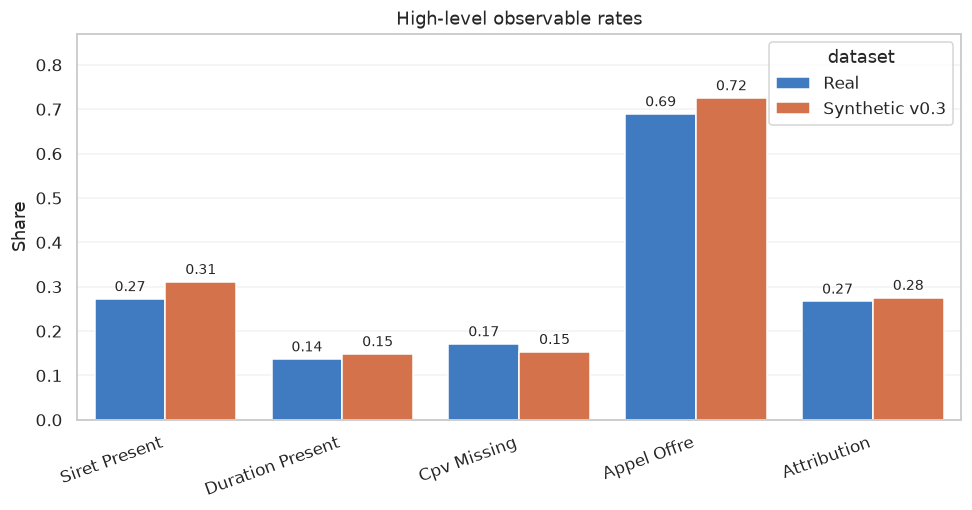

PosixPath('/home/senghakrou/survival-analysis/reports/figures/synthetic_benchmark/v0_3_real_synthetic_comparison/overview_observable_rates.png')

In [8]:
rate_cols = ["siret_present_share", "duration_present_share", "cpv_missing_share", "appel_offre_share", "attribution_share"]
rate_long = overview.melt(id_vars="dataset", value_vars=rate_cols, var_name="metric", value_name="rate")

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=rate_long, x="metric", y="rate", hue="dataset", palette=[REAL_COLOR, SYN_COLOR], ax=ax)
ax.set_title("High-level observable rates")
ax.set_xlabel("")
ax.set_ylabel("Share")
ax.set_ylim(0, min(1.05, max(0.15, rate_long["rate"].max() * 1.2)))
ax.set_xticklabels([label.get_text().replace("_share", "").replace("_", " ").title() for label in ax.get_xticklabels()], rotation=20, ha="right")
annotate_bar_values(ax, fmt="{:.2f}")
savefig("overview_observable_rates.png")

## Field Fidelity

In [9]:
conditional_summary = pd.read_csv(SOURCE_TABLE_DIR / "conditional_fidelity_summary_by_version.csv")
conditional_v3 = conditional_summary.query("version == @VERSION").copy()
conditional_v3["status_order"] = conditional_v3["status"].map({"PASS": 0}).fillna(1)
conditional_v3 = conditional_v3.sort_values(["status_order", "target"])
conditional_v3.to_csv(OUT_TABLES / "field_fidelity_summary_v0_3.csv", index=False)
conditional_v3[[
    "target", "eligible_cells", "eligible_real_population_share",
    "weighted_mean_abs_error_pp", "median_abs_error_pp", "p90_abs_error_pp",
    "weighted_signed_bias_pp", "wmae_regression_vs_v2_pp", "status"
]]

,target,eligible_cells,eligible_real_population_share,weighted_mean_abs_error_pp,median_abs_error_pp,p90_abs_error_pp,weighted_signed_bias_pp,wmae_regression_vs_v2_pp,status
1,cpv_missing,4.0,0.955438,2.092955,0.794975,2.414172,-1.874289,-0.481991,PASS
3,duration_present,29.0,0.934935,0.615890,0.362319,2.004549,-0.288066,0.107214,PASS
5,generic_repeated_text,8.0,0.955438,0.798590,0.828661,8.916992,0.326136,-0.598945,PASS
7,siret_present,29.0,0.934935,1.603932,1.009612,3.872726,-0.392479,-0.277102,PASS


/tmp/ipykernel_28538/3904241934.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([t.get_text().replace("_", " ").title() for t in ax.get_xticklabels()], rotation=15, ha="right")


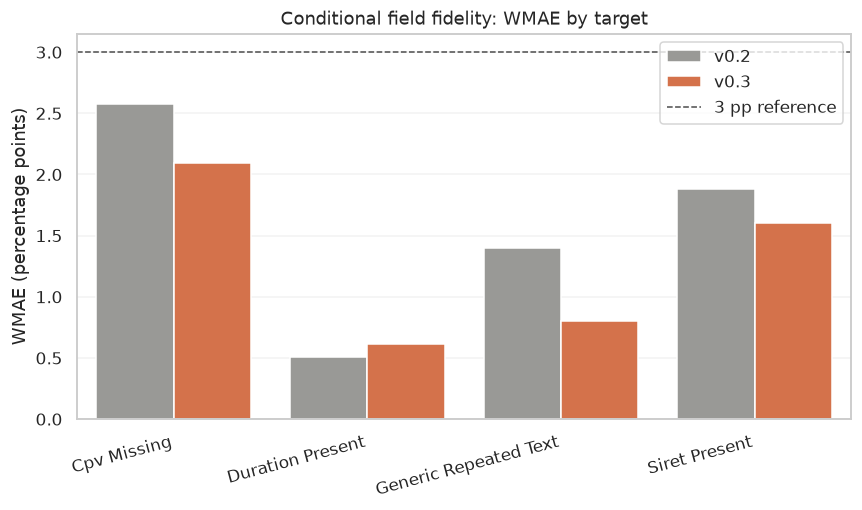

PosixPath('/home/senghakrou/survival-analysis/reports/figures/synthetic_benchmark/v0_3_real_synthetic_comparison/field_fidelity_wmae_by_target.png')

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.8))
plot_df = conditional_summary[conditional_summary["version"].isin([PREVIOUS_VERSION, VERSION])].copy()
plot_df["version_label"] = plot_df["version"].map({PREVIOUS_VERSION: "v0.2", VERSION: "v0.3"})
sns.barplot(
    data=plot_df,
    x="target",
    y="weighted_mean_abs_error_pp",
    hue="version_label",
    palette=[V2_COLOR, SYN_COLOR],
    ax=ax,
)
ax.axhline(3.0, color=NEUTRAL, linestyle="--", linewidth=1, label="3 pp reference")
ax.set_title("Conditional field fidelity: WMAE by target")
ax.set_xlabel("")
ax.set_ylabel("WMAE (percentage points)")
ax.set_xticklabels([t.get_text().replace("_", " ").title() for t in ax.get_xticklabels()], rotation=15, ha="right")
ax.legend(title="")
savefig("field_fidelity_wmae_by_target.png")

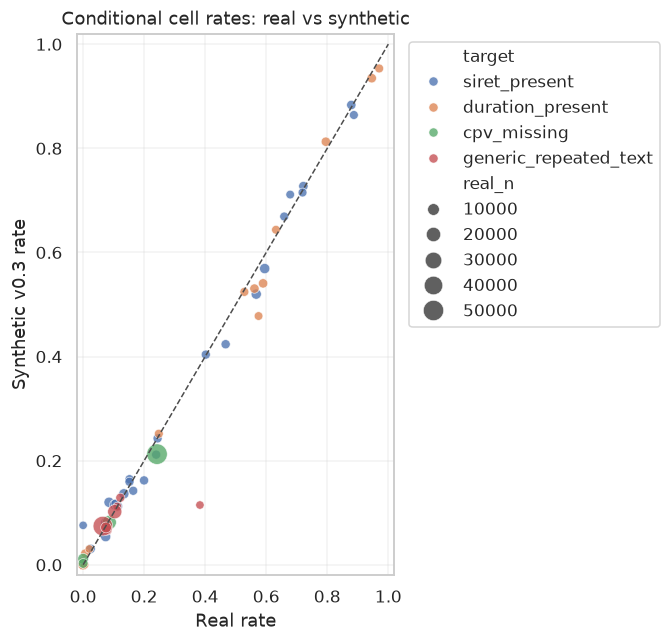

PosixPath('/home/senghakrou/survival-analysis/reports/figures/synthetic_benchmark/v0_3_real_synthetic_comparison/field_fidelity_cell_rate_scatter.png')

In [11]:
cell_files = {
    "siret_present": SOURCE_TABLE_DIR / f"conditional_fidelity_siret_present_{VERSION}.csv",
    "duration_present": SOURCE_TABLE_DIR / f"conditional_fidelity_duration_present_{VERSION}.csv",
    "cpv_missing": SOURCE_TABLE_DIR / f"conditional_fidelity_cpv_missing_{VERSION}.csv",
    "generic_repeated_text": SOURCE_TABLE_DIR / f"conditional_fidelity_generic_repeated_text_{VERSION}.csv",
}
cell_frames = []
for target, path in cell_files.items():
    frame = pd.read_csv(path)
    frame["target"] = target
    cell_frames.append(frame)
field_cells = pd.concat(cell_frames, ignore_index=True, sort=False)
field_cells["eligible_cell"] = field_cells["eligible_cell"].fillna(False).astype(bool)
field_cells = field_cells.rename(
    columns={
        "rate_real": "real_rate",
        "rate_synthetic": "synthetic_rate",
        "n_real": "real_n",
        "n_synthetic": "synthetic_n",
    }
)
field_cells.to_csv(OUT_TABLES / "field_fidelity_cell_rates_v0_3.csv", index=False)

scatter_df = field_cells[field_cells["eligible_cell"]].dropna(subset=["real_rate", "synthetic_rate"]).copy()
fig, ax = plt.subplots(figsize=(6.3, 6.0))
sns.scatterplot(
    data=scatter_df,
    x="real_rate",
    y="synthetic_rate",
    hue="target",
    size="real_n",
    sizes=(30, 180),
    alpha=0.78,
    ax=ax,
)
ax.plot([0, 1], [0, 1], color=NEUTRAL, linestyle="--", linewidth=1)
ax.set_title("Conditional cell rates: real vs synthetic")
ax.set_xlabel("Real rate")
ax.set_ylabel("Synthetic v0.3 rate")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="")
savefig("field_fidelity_cell_rate_scatter.png")

## Temporal Similarity

In [12]:
temporal_summary = pd.read_csv(SOURCE_TABLE_DIR / "temporal_summary_metrics.csv")
followup = pd.read_csv(SOURCE_TABLE_DIR / "temporal_followup_runway_comparison.csv")
temporal_summary.to_csv(OUT_TABLES / "temporal_summary_metrics.csv", index=False)
followup.to_csv(OUT_TABLES / "temporal_followup_runway_comparison.csv", index=False)
temporal_summary

,dimension,metric,value,threshold,status
0,year_share,TVD,0.151032,0.2,PASS
1,schema_by_year,WMAE_pp,0.339414,3.0,PASS
2,notice_type_by_year,WMAE_pp,3.802912,5.0,PASS
3,month_share,TVD,0.178480,0.2,PASS


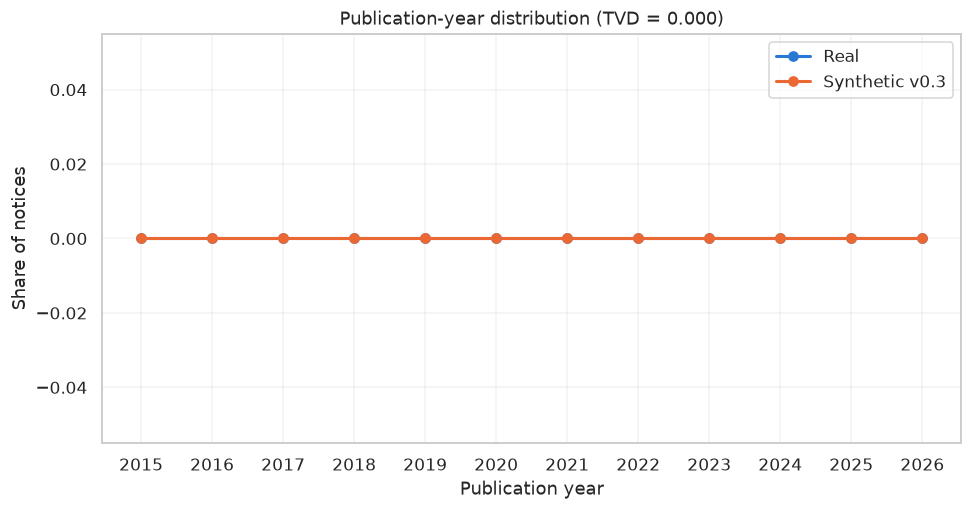

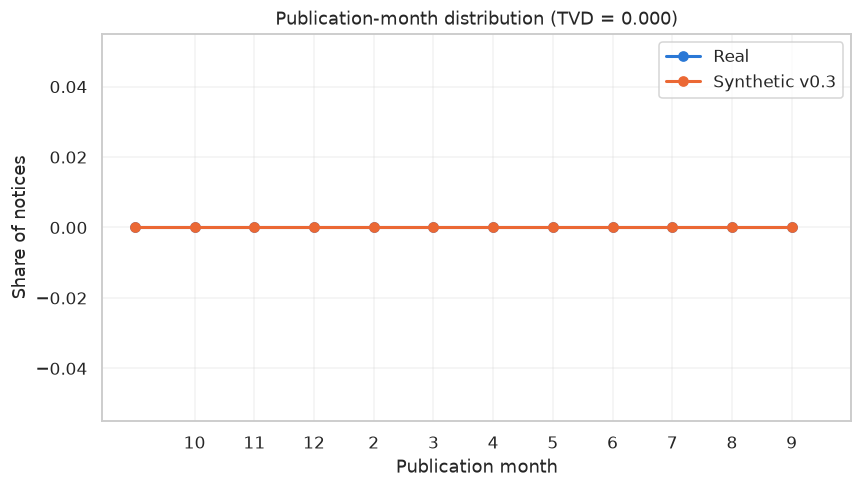

PosixPath('/home/senghakrou/survival-analysis/reports/figures/synthetic_benchmark/v0_3_real_synthetic_comparison/temporal_publication_month_line.png')

In [13]:
year_share = aligned_share(comparison_frame, "dataset", "publication_year", ["Real", "Synthetic v0.3"])
year_wide = wide_real_synthetic(year_share, "publication_year")
month_share = aligned_share(comparison_frame, "dataset", "publication_month", ["Real", "Synthetic v0.3"])
month_wide = wide_real_synthetic(month_share, "publication_month")
year_wide.to_csv(OUT_TABLES / "publication_year_share_comparison.csv", index=False)
month_wide.to_csv(OUT_TABLES / "publication_month_share_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
for label, color in [("Real", REAL_COLOR), ("Synthetic v0.3", SYN_COLOR)]:
    subset = year_share[year_share["dataset"].eq(label)]
    ax.plot(subset["publication_year"], subset["share"], marker="o", linewidth=2, label=label, color=color)
ax.set_title(f"Publication-year distribution (TVD = {tvd_from_shares(year_wide):.3f})")
ax.set_xlabel("Publication year")
ax.set_ylabel("Share of notices")
ax.legend()
savefig("temporal_publication_year_line.png")

fig, ax = plt.subplots(figsize=(8, 4.6))
for label, color in [("Real", REAL_COLOR), ("Synthetic v0.3", SYN_COLOR)]:
    subset = month_share[month_share["dataset"].eq(label)]
    ax.plot(subset["publication_month"], subset["share"], marker="o", linewidth=2, label=label, color=color)
ax.set_title(f"Publication-month distribution (TVD = {tvd_from_shares(month_wide):.3f})")
ax.set_xlabel("Publication month")
ax.set_ylabel("Share of notices")
ax.set_xticks(range(1, 13))
ax.legend()
savefig("temporal_publication_month_line.png")

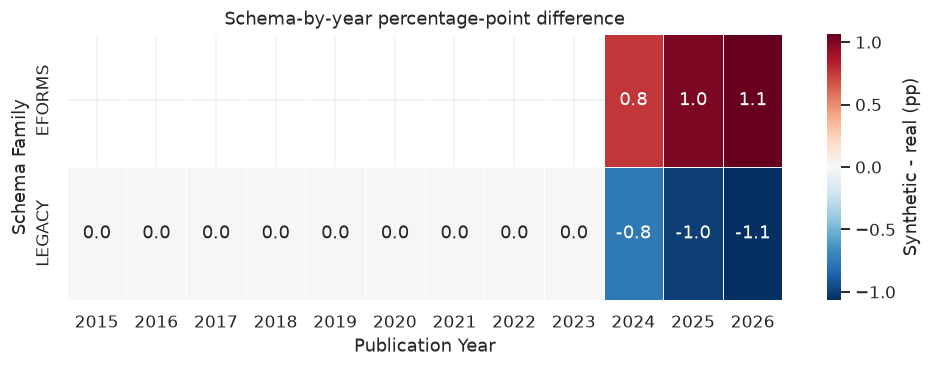

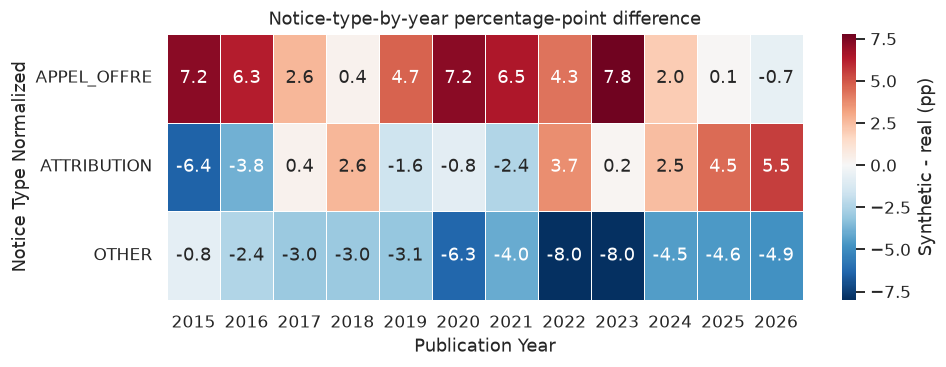

In [14]:
schema_year = pd.read_csv(SOURCE_TABLE_DIR / "temporal_schema_by_year_comparison.csv")
notice_year = pd.read_csv(SOURCE_TABLE_DIR / "temporal_notice_type_by_year_comparison.csv")
schema_year.to_csv(OUT_TABLES / "temporal_schema_by_year_comparison.csv", index=False)
notice_year.to_csv(OUT_TABLES / "temporal_notice_type_by_year_comparison.csv", index=False)

def heatmap_ppdiff(frame: pd.DataFrame, row: str, col: str, filename: str, title: str) -> None:
    diff_col = "diff_pp" if "diff_pp" in frame.columns else "signed_diff_pp"
    pivot = frame.pivot_table(index=row, columns=col, values=diff_col, aggfunc="mean").sort_index()
    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.5 * len(pivot))))
    sns.heatmap(
        pivot,
        cmap="RdBu_r",
        center=0,
        annot=True,
        fmt=".1f",
        linewidths=0.5,
        cbar_kws={"label": "Synthetic - real (pp)"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel(row.replace("_", " ").title())
    savefig(filename)

heatmap_ppdiff(schema_year, "schema_family", "publication_year", "temporal_schema_by_year_ppdiff_heatmap.png", "Schema-by-year percentage-point difference")
heatmap_ppdiff(notice_year, "notice_type_normalized", "publication_year", "temporal_notice_type_by_year_ppdiff_heatmap.png", "Notice-type-by-year percentage-point difference")

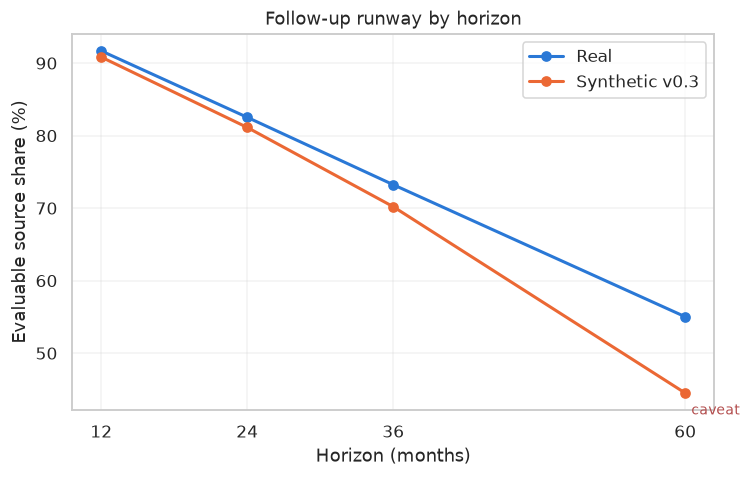

,horizon_months,real_evaluable_rate,synthetic_evaluable_rate,abs_diff_pp,threshold_abs_pp,status
0,12,0.916784,0.908246,0.853763,3.0,PASS
1,24,0.825178,0.811213,1.396438,3.0,PASS
2,36,0.732260,0.701932,3.032734,5.0,PASS
3,60,0.550158,0.444937,10.522058,5.0,NEEDS_REVISION


In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
followup_plot = followup.copy()
followup_plot["real_pct"] = followup_plot["real_evaluable_rate"] * 100
followup_plot["synthetic_pct"] = followup_plot["synthetic_evaluable_rate"] * 100
ax.plot(followup_plot["horizon_months"], followup_plot["real_pct"], marker="o", label="Real", color=REAL_COLOR, linewidth=2)
ax.plot(followup_plot["horizon_months"], followup_plot["synthetic_pct"], marker="o", label="Synthetic v0.3", color=SYN_COLOR, linewidth=2)
for _, row in followup_plot.iterrows():
    if row["status"] != "PASS":
        ax.annotate("caveat", (row["horizon_months"], row["synthetic_pct"]), textcoords="offset points", xytext=(4, -14), fontsize=9, color=DIFF_COLOR)
ax.set_title("Follow-up runway by horizon")
ax.set_xlabel("Horizon (months)")
ax.set_ylabel("Evaluable source share (%)")
ax.set_xticks(followup_plot["horizon_months"])
ax.legend()
savefig("temporal_followup_runway_line.png")
followup[["horizon_months", "real_evaluable_rate", "synthetic_evaluable_rate", "abs_diff_pp", "threshold_abs_pp", "status"]]

## Candidate Environment

In [16]:
candidate_summary = pd.read_csv(SOURCE_TABLE_DIR / "candidate_environment_summary_metrics.csv")
candidate_gate = pd.read_csv(SOURCE_TABLE_DIR / "candidate_environment_validation_gate_by_version.csv")
by_key_v2 = pd.read_csv(SOURCE_TABLE_DIR / f"candidate_environment_by_buyer_key_type_{PREVIOUS_VERSION}.csv")
by_key_v3 = pd.read_csv(SOURCE_TABLE_DIR / f"candidate_environment_by_buyer_key_type_{VERSION}.csv")
candidate_summary.to_csv(OUT_TABLES / "candidate_environment_summary_metrics.csv", index=False)
candidate_gate.to_csv(OUT_TABLES / "candidate_environment_validation_gate_by_version.csv", index=False)
candidate_summary

,scope,n_sources,zero_candidate_rate,mean_candidate_count,median_candidate_count,p75_candidate_count,p90_candidate_count,p95_candidate_count,p99_candidate_count,max_candidate_count,cap_reached_rate
0,real_layer1_algorithm_scope,3159,0.608737,1.942703,0.0,2.0,6.0,10.0,22.0,30,0.000633
1,v0_2_conditional_revision_layer1_algorithm_scope,354,0.903955,0.152542,0.0,0.0,0.0,1.0,2.0,3,0.000000
2,v0_3_temporal_candidate_revision_layer1_algorithm_scope,395,0.630380,0.637975,0.0,1.0,2.0,3.0,6.0,8,0.000000


/tmp/ipykernel_28538/4057228218.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=candidate_plot, x="scope_label", y="zero_candidate_rate", palette=[REAL_COLOR, V2_COLOR, SYN_COLOR], ax=axes[0])


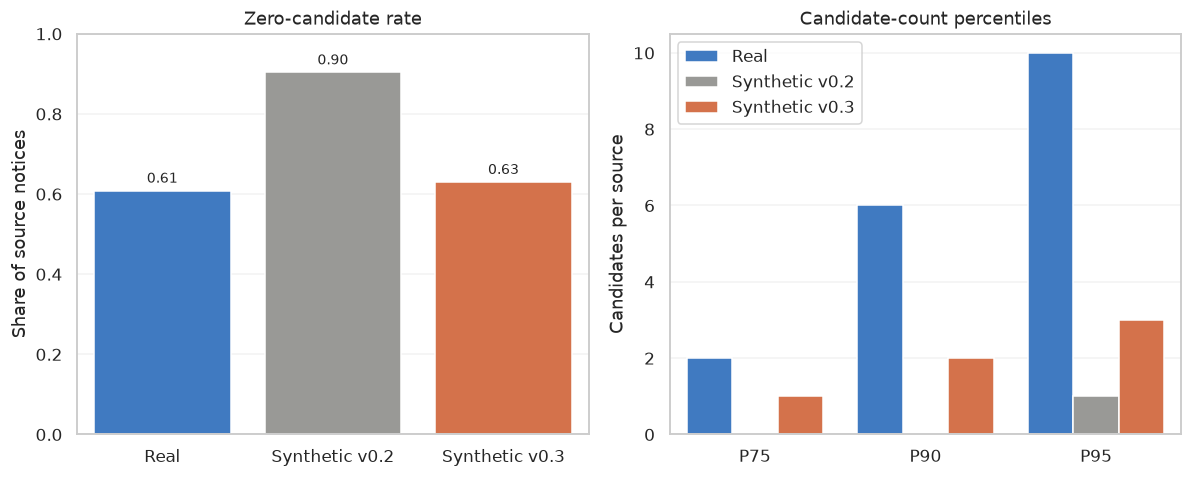

PosixPath('/home/senghakrou/survival-analysis/reports/figures/synthetic_benchmark/v0_3_real_synthetic_comparison/candidate_environment_summary_bars.png')

In [17]:
candidate_plot = candidate_summary.copy()
candidate_plot["scope_label"] = candidate_plot["scope"].map(
    {
        "real_layer1_algorithm_scope": "Real",
        f"{PREVIOUS_VERSION}_layer1_algorithm_scope": "Synthetic v0.2",
        f"{VERSION}_layer1_algorithm_scope": "Synthetic v0.3",
    }
).fillna(candidate_plot["scope"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(data=candidate_plot, x="scope_label", y="zero_candidate_rate", palette=[REAL_COLOR, V2_COLOR, SYN_COLOR], ax=axes[0])
axes[0].set_title("Zero-candidate rate")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share of source notices")
axes[0].set_ylim(0, 1)
annotate_bar_values(axes[0], fmt="{:.2f}")

percentile_long = candidate_plot.melt(
    id_vars=["scope_label"],
    value_vars=["p75_candidate_count", "p90_candidate_count", "p95_candidate_count"],
    var_name="percentile",
    value_name="candidate_count",
)
percentile_long["percentile"] = percentile_long["percentile"].str.extract(r"(p\d+)")[0].str.upper()
sns.barplot(data=percentile_long, x="percentile", y="candidate_count", hue="scope_label", palette=[REAL_COLOR, V2_COLOR, SYN_COLOR], ax=axes[1])
axes[1].set_title("Candidate-count percentiles")
axes[1].set_xlabel("")
axes[1].set_ylabel("Candidates per source")
axes[1].legend(title="")
savefig("candidate_environment_summary_bars.png")

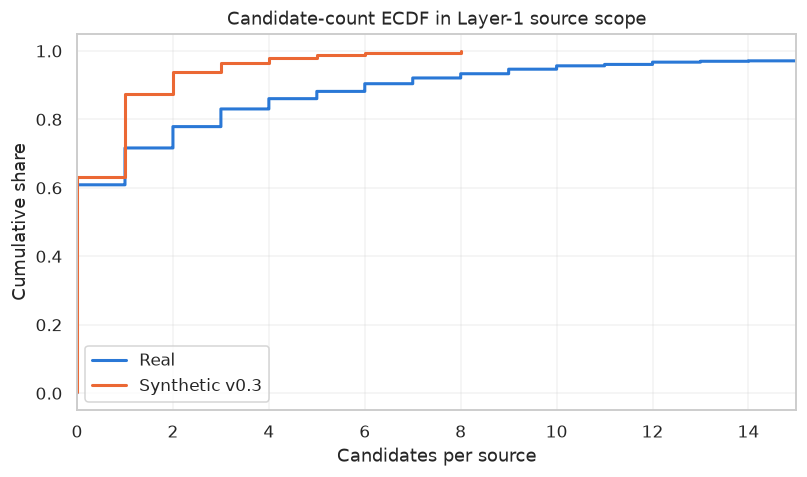

In [18]:
real_counts = pd.read_csv(PROJECT_ROOT / "reports/tables/synthetic_benchmark/v0_2_conditional_revision/candidate_counts_real_layer1_algorithm_scope.csv")
syn_counts = pd.read_csv(SOURCE_TABLE_DIR / f"candidate_counts_{VERSION}_layer1_algorithm_scope.csv")
if "scope" not in real_counts.columns:
    real_counts["scope"] = "real"
if "scope" not in syn_counts.columns:
    syn_counts["scope"] = "synthetic_v0_3"

# Use saved count tables for exact distribution evidence.
real_candidate_counts = real_counts["candidate_count"] if "candidate_count" in real_counts.columns else real_counts.iloc[:, -1]
syn_candidate_counts = syn_counts["candidate_count"] if "candidate_count" in syn_counts.columns else syn_counts.iloc[:, -1]

plot_ecdf(
    real_candidate_counts,
    syn_candidate_counts,
    "Candidate-count ECDF in Layer-1 source scope",
    "Candidates per source",
    "candidate_count_ecdf.png",
    xlim=(0, 15),
)

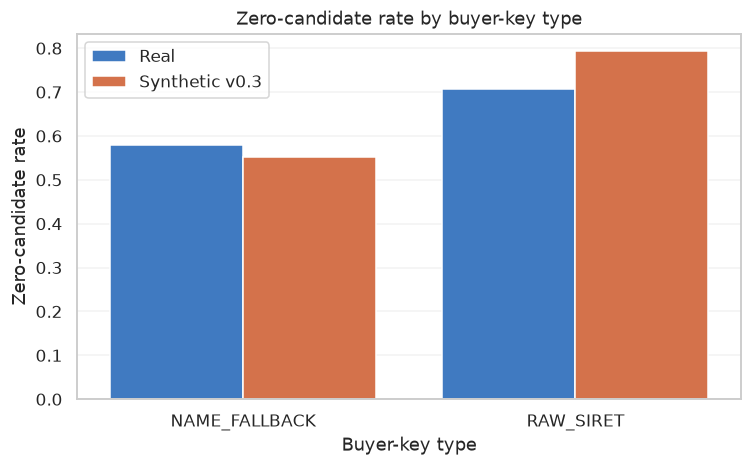

,version,buyer_key_type,n_real,n_synthetic,real_zero_candidate_rate,synthetic_zero_candidate_rate,abs_diff_pp,eligible_for_gate
0,v0_3_temporal_candidate_revision,NAME_FALLBACK,2446,270,0.580131,0.551852,2.827897,True
1,v0_3_temporal_candidate_revision,RAW_SIRET,713,116,0.706872,0.793103,8.623108,True


In [19]:
by_key_v3.to_csv(OUT_TABLES / "candidate_environment_by_buyer_key_type_v0_3.csv", index=False)
if {"buyer_key_type", "real_zero_candidate_rate", "synthetic_zero_candidate_rate"}.issubset(by_key_v3.columns):
    by_key_plot = by_key_v3.copy()
    by_key_long = by_key_plot.melt(
        id_vars=["buyer_key_type"],
        value_vars=["real_zero_candidate_rate", "synthetic_zero_candidate_rate"],
        var_name="dataset",
        value_name="zero_candidate_rate",
    )
    by_key_long["dataset"] = by_key_long["dataset"].map({"real_zero_candidate_rate": "Real", "synthetic_zero_candidate_rate": "Synthetic v0.3"})
    fig, ax = plt.subplots(figsize=(7, 4.4))
    sns.barplot(data=by_key_long, x="buyer_key_type", y="zero_candidate_rate", hue="dataset", palette=[REAL_COLOR, SYN_COLOR], ax=ax)
    ax.set_title("Zero-candidate rate by buyer-key type")
    ax.set_xlabel("Buyer-key type")
    ax.set_ylabel("Zero-candidate rate")
    ax.legend(title="")
    savefig("candidate_zero_rate_by_buyer_key_type.png")
by_key_v3

## Distribution Checks

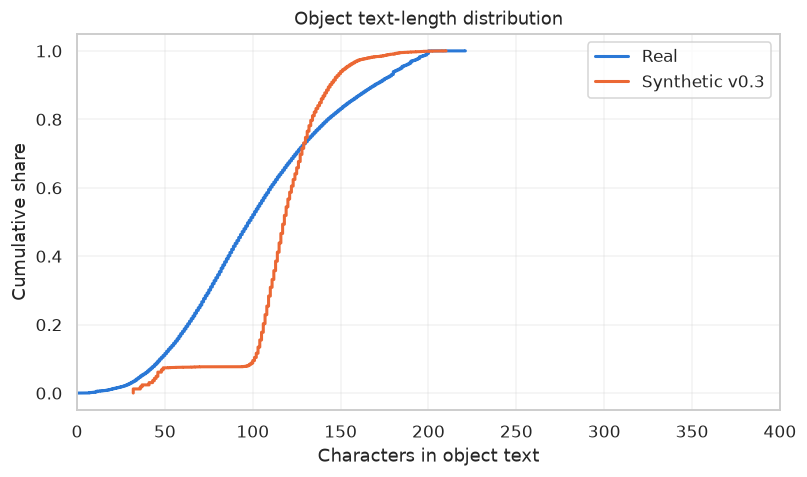

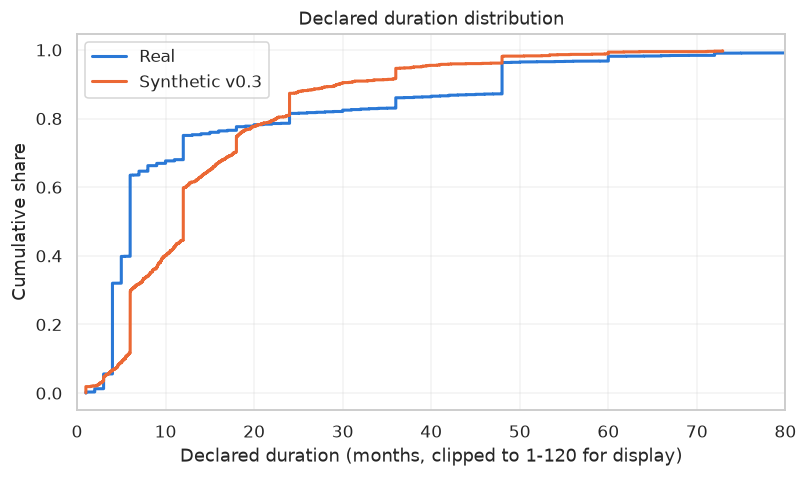

In [20]:
plot_ecdf(
    real["text_length_calc"],
    synthetic["text_length_calc"],
    "Object text-length distribution",
    "Characters in object text",
    "distribution_text_length_ecdf.png",
    xlim=(0, 400),
)

duration_real = real["duration_for_distribution"].where(real["duration_for_distribution"].between(1, 120))
duration_syn = synthetic["duration_for_distribution"].where(synthetic["duration_for_distribution"].between(1, 120))
plot_ecdf(
    duration_real,
    duration_syn,
    "Declared duration distribution",
    "Declared duration (months, clipped to 1-120 for display)",
    "distribution_declared_duration_ecdf.png",
    xlim=(0, 80),
)

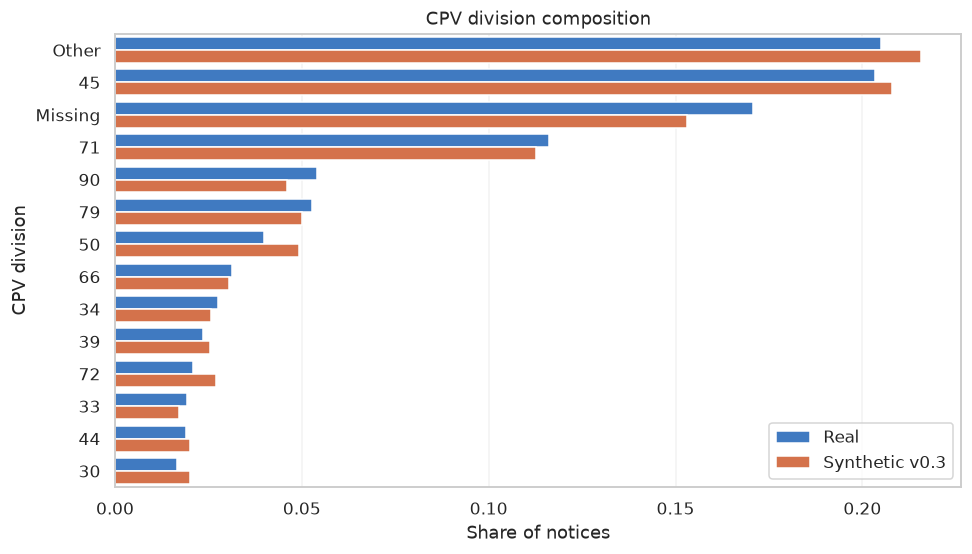

dataset,cpv_division_display,Real,Synthetic v0.3,diff_pp,abs_diff_pp
13,Other,0.205027,0.215711,1.068412,1.068412
5,45,0.203254,0.207792,0.453777,0.453777
12,Missing,0.170616,0.152993,-1.762221,1.762221
8,71,0.116056,0.112765,-0.329064,0.329064
11,90,0.054134,0.046141,-0.799337,0.799337
10,79,0.052716,0.049942,-0.277424,0.277424
6,50,0.039859,0.049203,0.934369,0.934369
7,66,0.031174,0.030514,-0.065936,0.065936
2,34,0.027522,0.025657,-0.186480,0.186480
3,39,0.023611,0.025446,0.183550,0.183550


In [21]:
top_real_divisions = real["cpv_division"].dropna().astype(str).value_counts().head(12).index.tolist()
division_frame = comparison_frame.copy()
division_frame["cpv_division_display"] = division_frame["cpv_division"].astype("string").fillna("Missing")
division_frame.loc[~division_frame["cpv_division_display"].isin(top_real_divisions + ["Missing"]), "cpv_division_display"] = "Other"
division_share = aligned_share(division_frame, "dataset", "cpv_division_display", ["Real", "Synthetic v0.3"])
division_wide = wide_real_synthetic(division_share, "cpv_division_display").sort_values("Real", ascending=False)
division_wide.to_csv(OUT_TABLES / "cpv_division_share_comparison.csv", index=False)

ordered_divisions = division_wide["cpv_division_display"].tolist()
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.barplot(
    data=division_share,
    y="cpv_division_display",
    x="share",
    hue="dataset",
    order=ordered_divisions,
    palette=[REAL_COLOR, SYN_COLOR],
    ax=ax,
)
ax.set_title("CPV division composition")
ax.set_xlabel("Share of notices")
ax.set_ylabel("CPV division")
ax.legend(title="")
savefig("distribution_cpv_division_share.png")
division_wide.head(12)

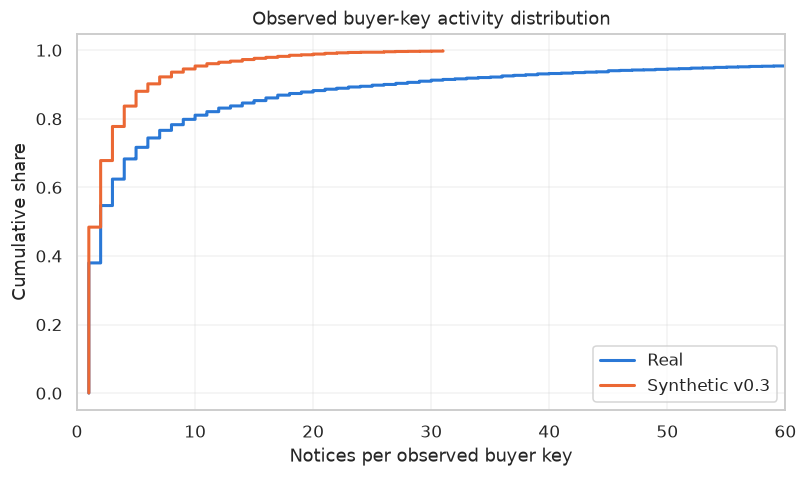

,count,mean,std,min,50%,75%,90%,95%,99%,max
dataset,,,,,,,,,,
Real,5268.0,16.063591,80.023325,1.0,2.0,7.0,26.3,55.0,260.32,3185.0
Synthetic v0.3,2808.0,3.372863,11.312742,1.0,2.0,3.0,6.0,10.0,21.00,328.0


In [22]:
def buyer_activity_distribution_real(frame: pd.DataFrame) -> pd.DataFrame:
    counts = frame.groupby("buyer_key", dropna=False)["notice_id_compare"].size()
    return pd.DataFrame({"dataset": "Real", "notice_count_per_buyer_key": counts.values})

def buyer_activity_distribution_synthetic(frame: pd.DataFrame) -> pd.DataFrame:
    # Approximate buyer activity in observed synthetic data using the most reliable observable key available.
    key = frame["buyer_siret_raw"].fillna(frame["buyer_siren_raw"]).fillna(frame["buyer_name_raw"].fillna("MISSING"))
    counts = frame.assign(observed_buyer_key=key).groupby("observed_buyer_key", dropna=False)["notice_id_compare"].size()
    return pd.DataFrame({"dataset": "Synthetic v0.3", "notice_count_per_buyer_key": counts.values})

buyer_activity = pd.concat(
    [buyer_activity_distribution_real(real), buyer_activity_distribution_synthetic(synthetic)],
    ignore_index=True,
)
buyer_activity.to_csv(OUT_TABLES / "buyer_activity_proxy_distribution.csv", index=False)
plot_ecdf(
    buyer_activity.loc[buyer_activity["dataset"].eq("Real"), "notice_count_per_buyer_key"],
    buyer_activity.loc[buyer_activity["dataset"].eq("Synthetic v0.3"), "notice_count_per_buyer_key"],
    "Observed buyer-key activity distribution",
    "Notices per observed buyer key",
    "distribution_buyer_activity_ecdf.png",
    xlim=(0, 60),
)
buyer_activity.groupby("dataset")["notice_count_per_buyer_key"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

## Final Evidence Table

In [23]:
freeze_gate = pd.read_csv(SOURCE_TABLE_DIR / "temporal_candidate_freeze_gate.csv")
truth_checks = pd.read_csv(SOURCE_TABLE_DIR / "temporal_truth_sanity_checks.csv")

final_evidence = pd.DataFrame(
    [
        {
            "dimension": "conditional_fidelity",
            "headline": "All v0.3 conditional targets pass",
            "evidence": "; ".join(
                f"{row.target}: WMAE {row.weighted_mean_abs_error_pp:.2f} pp"
                for row in conditional_v3.itertuples()
            ),
            "status": "PASS" if conditional_v3["status"].eq("PASS").all() else "NEEDS_REVISION",
        },
        {
            "dimension": "temporal_similarity",
            "headline": "Calendar and 12/24-month runway pass",
            "evidence": "; ".join(
                f"{row.dimension} {row.metric}={row.value:.3f}"
                for row in temporal_summary.itertuples()
            ),
            "status": "PASS" if temporal_summary["status"].eq("PASS").all() else "NEEDS_REVISION",
        },
        {
            "dimension": "candidate_environment",
            "headline": "Layer-1 candidate environment passes",
            "evidence": "zero-candidate rate: real 60.9%, synthetic v0.3 63.0%; p75/p90/p95: real 2/6/10, synthetic 1/2/3",
            "status": "PASS",
        },
        {
            "dimension": "structural_truth",
            "headline": "Hidden truth is coherent and not leaked",
            "evidence": "observed truth columns = 0; metadata validation PASS; true gaps >6m = 81.2%",
            "status": "PASS",
        },
        {
            "dimension": "caveat",
            "headline": "60-month follow-up remains weaker",
            "evidence": "60m follow-up absolute error = 10.52 pp; documented non-blocking caveat",
            "status": "CAVEAT",
        },
    ]
)
final_evidence.to_csv(OUT_TABLES / "final_evidence_summary.csv", index=False)
freeze_gate.to_csv(OUT_TABLES / "temporal_candidate_freeze_gate.csv", index=False)
truth_checks.to_csv(OUT_TABLES / "temporal_truth_sanity_checks.csv", index=False)
final_evidence

,dimension,headline,evidence,status
0,conditional_fidelity,All v0.3 conditional targets pass,cpv_missing: WMAE 2.09 pp; duration_present: WMAE 0.62 pp; generic_repeated_text: WMAE 0.80 pp; siret_present: WMAE ...,PASS
1,temporal_similarity,Calendar and 12/24-month runway pass,year_share TVD=0.151; schema_by_year WMAE_pp=0.339; notice_type_by_year WMAE_pp=3.803; month_share TVD=0.178,PASS
2,candidate_environment,Layer-1 candidate environment passes,"zero-candidate rate: real 60.9%, synthetic v0.3 63.0%; p75/p90/p95: real 2/6/10, synthetic 1/2/3",PASS
3,structural_truth,Hidden truth is coherent and not leaked,observed truth columns = 0; metadata validation PASS; true gaps >6m = 81.2%,PASS
4,caveat,60-month follow-up remains weaker,60m follow-up absolute error = 10.52 pp; documented non-blocking caveat,CAVEAT


/tmp/ipykernel_28538/1164294945.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([label.get_text().replace("_", " ").title() for label in ax.get_xticklabels()], rotation=15, ha="right")


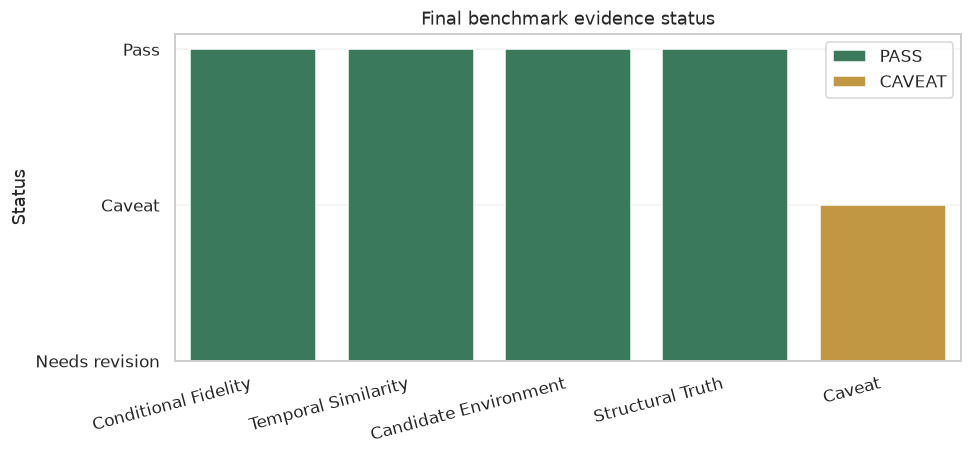

PosixPath('/home/senghakrou/survival-analysis/reports/figures/synthetic_benchmark/v0_3_real_synthetic_comparison/final_evidence_status.png')

In [24]:
status_plot = final_evidence.copy()
status_plot["plot_value"] = status_plot["status"].map({"PASS": 1.0, "CAVEAT": 0.5, "NEEDS_REVISION": 0.0})
palette = {"PASS": "#2f855a", "CAVEAT": "#d69e2e", "NEEDS_REVISION": "#c53030"}
fig, ax = plt.subplots(figsize=(9, 4.3))
sns.barplot(data=status_plot, x="dimension", y="plot_value", hue="status", dodge=False, palette=palette, ax=ax)
ax.set_title("Final benchmark evidence status")
ax.set_xlabel("")
ax.set_ylabel("Status")
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["Needs revision", "Caveat", "Pass"])
ax.set_xticklabels([label.get_text().replace("_", " ").title() for label in ax.get_xticklabels()], rotation=15, ha="right")
ax.legend(title="")
savefig("final_evidence_status.png")

## Takeaways

1. **The v0.3 synthetic benchmark is ready for linkage-algorithm testing.**
   The final freeze gate is `READY_FOR_LINKAGE` because conditional fidelity,
   temporal validation, candidate environment, and structural truth all pass.

2. **The strongest visual evidence is the candidate environment.** The v0.3
   zero-candidate rate is close to the real Layer-1 source scope, so the
   production candidate generator now sees a realistic enough test
   environment.

3. **The benchmark is credible, not perfect.** The 60-month follow-up runway
   remains a caveat, and the candidate-count upper tail is still lighter than
   the real corpus.

4. **The synthetic dataset is not a replacement for real truth.** It is a
   controlled benchmark with hidden labels, designed to evaluate whether
   linkage algorithms can recover known synthetic recurrence structure under
   realistic observed-data corruption.
